Project Topic - Predicting Turbine Decay Coefficient for a Gas Turbine using historical data

About the Project

Data Source: The data was obtained from the UC Irvine Machine Learning Repository https://archive.ics.uci.edu/dataset/316/condition+based+maintenance+of+naval+propulsion+plants

Citation: Coraddu,Andrea, Oneto,Luca, Ghio,Alessandro, Savio,Stefano, Anguita,Davide, and Figari,Massimo. (2014). Condition Based Maintenance of Naval Propulsion Plants. UCI Machine Learning Repository. https://doi.org/10.24432/C5K31K.

Dataset Description: The data was obtained in two text file sets - One with the features and another with the actual data. I combined both to csv, generating a new 
file with size 1.3mb. The dataset consists of 18 columns (16 features and 2 predictors - Compressor Decay Coefficient and Turbine Decay Coefficient). I removed the Compressor Decay Coefficient reducing the columns to 17.

Project and data Summary: Data have been generated from a sophisticated simulator of a Gas Turbines (GT), mounted on a Frigate characterized by a Combined Diesel Electric And Gas (CODLAG) propulsion plant type. The experiments have been carried out by means of a numerical simulator of a naval vessel (Frigate) characterized by a Gas Turbine (GT) propulsion plant. 

Project Scope and Task: For this project, I am intending to predict the Gas Turbine Decay coefficient from the simulation data. As the features are numerical, I will be using a simple Linear Regression algorithim from the scikit-learn package, for a supervised machine learning task.

Importing Required Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from scipy.stats import boxcox
from scipy.stats.mstats import normaltest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from sklearn.pipeline import Pipeline

Data Cleaning

For the data cleaning portion of this project, I performed the following:
- Checked for null values
- Confirmed all required columns were in float data type
- Removed unneeded column
- Confirmed the data statistical distribution using data.describe()

In [5]:
#Importing and understanding the data

data = pd.read_csv(r'C:\Users\godsw\OneDrive\Desktop\Study\U of Colorado Data Science\Introduction to Machine Learning\Final Project\Turbine data.csv')
data.head()

,Lever position (lp) [ ],Ship speed (v) [knots],Gas Turbine shaft torque (GTT) [kN m],Gas Turbine rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],HP Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],Gas Turbine exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient.,GT Turbine decay state coefficient.
0,1.14,3.0,289.96,1349.49,6677.38,7.58,7.58,464.01,288.0,550.56,1.10,1.0,5.95,1.02,7.14,0.08,0.95,0.98
1,2.09,6.0,6960.18,1376.17,6828.47,28.20,28.20,635.40,288.0,581.66,1.33,1.0,7.28,1.02,10.66,0.29,0.95,0.98
2,3.14,9.0,8379.23,1386.76,7111.81,60.36,60.36,606.00,288.0,587.59,1.39,1.0,7.57,1.02,13.09,0.26,0.95,0.98
3,4.16,12.0,14724.40,1547.47,7792.63,113.77,113.77,661.47,288.0,613.85,1.66,1.0,9.01,1.02,18.11,0.36,0.95,0.98
4,5.14,15.0,21636.43,1924.31,8494.78,175.31,175.31,731.49,288.0,645.64,2.08,1.0,11.20,1.03,26.37,0.52,0.95,0.98


In [6]:
#Checking for missing values in the dataset

data.isnull().values.any()


False

In [22]:
#Removing white space from column names
data.columns = data.columns.str.replace("'", "")
data.columns = data.columns.str.strip()


In [23]:
print(data.columns)

Index(['Lever position (lp) [ ]', 'Ship speed (v) [knots]',
       'Gas Turbine shaft torque (GTT) [kN m]',
       'Gas Turbine rate of revolutions (GTn) [rpm]',
       'Gas Generator rate of revolutions (GGn) [rpm]',
       'Starboard Propeller Torque (Ts) [kN]',
       'Port Propeller Torque (Tp) [kN]',
       'HP Turbine exit temperature (T48) [C]',
       'GT Compressor inlet air temperature (T1) [C]',
       'GT Compressor outlet air temperature (T2) [C]',
       'HP Turbine exit pressure (P48) [bar]',
       'GT Compressor inlet air pressure (P1) [bar]',
       'GT Compressor outlet air pressure (P2) [bar]',
       'Gas Turbine exhaust gas pressure (Pexh) [bar]',
       'Turbine Injecton Control (TIC) [%]', 'Fuel flow (mf) [kg/s]',
       'GT Compressor decay state coefficient.',
       'GT Turbine decay state coefficient.'],
      dtype='object')


In [25]:
for col in data.columns:
    print(f"{col}")


Lever position (lp) [ ]
Ship speed (v) [knots]
Gas Turbine shaft torque (GTT) [kN m]
Gas Turbine rate of revolutions (GTn) [rpm]
Gas Generator rate of revolutions (GGn) [rpm]
Starboard Propeller Torque (Ts) [kN]
Port Propeller Torque (Tp) [kN]
HP Turbine exit temperature (T48) [C]
GT Compressor inlet air temperature (T1) [C]
GT Compressor outlet air temperature (T2) [C]
HP Turbine exit pressure (P48) [bar]
GT Compressor inlet air pressure (P1) [bar]
GT Compressor outlet air pressure (P2) [bar]
Gas Turbine exhaust gas pressure (Pexh) [bar]
Turbine Injecton Control (TIC) [%]
Fuel flow (mf) [kg/s]
GT Compressor decay state coefficient.
GT Turbine decay state coefficient.


In [28]:
#This dataset provides the opportunity to predict either decay state of a rotating equipment given by either the GT Comp Decay State
#Coeff or the GT Turbine Decay State Coeff.

#We will be predicting the GT Turbine Decay State so will drop the Compressor Decay State

column_to_drop = [col for col in data.columns if "GT Compressor decay state coefficient." in col]
if column_to_drop:
    data = data.drop(column_to_drop, axis=1)

In [29]:
data.head()

,Lever position (lp) [ ],Ship speed (v) [knots],Gas Turbine shaft torque (GTT) [kN m],Gas Turbine rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],HP Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],Gas Turbine exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Turbine decay state coefficient.
0,1.14,3.0,289.96,1349.49,6677.38,7.58,7.58,464.01,288.0,550.56,1.10,1.0,5.95,1.02,7.14,0.08,0.98
1,2.09,6.0,6960.18,1376.17,6828.47,28.20,28.20,635.40,288.0,581.66,1.33,1.0,7.28,1.02,10.66,0.29,0.98
2,3.14,9.0,8379.23,1386.76,7111.81,60.36,60.36,606.00,288.0,587.59,1.39,1.0,7.57,1.02,13.09,0.26,0.98
3,4.16,12.0,14724.40,1547.47,7792.63,113.77,113.77,661.47,288.0,613.85,1.66,1.0,9.01,1.02,18.11,0.36,0.98
4,5.14,15.0,21636.43,1924.31,8494.78,175.31,175.31,731.49,288.0,645.64,2.08,1.0,11.20,1.03,26.37,0.52,0.98


In [30]:
#let's get some info about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lever position (lp) [ ]                        11934 non-null  float64
 1   Ship speed (v) [knots]                         11934 non-null  float64
 2   Gas Turbine shaft torque (GTT) [kN m]          11934 non-null  float64
 3   Gas Turbine rate of revolutions (GTn) [rpm]    11934 non-null  float64
 4   Gas Generator rate of revolutions (GGn) [rpm]  11934 non-null  float64
 5   Starboard Propeller Torque (Ts) [kN]           11934 non-null  float64
 6   Port Propeller Torque (Tp) [kN]                11934 non-null  float64
 7   HP Turbine exit temperature (T48) [C]          11934 non-null  float64
 8   GT Compressor inlet air temperature (T1) [C]   11934 non-null  float64
 9   GT Compressor outlet air temperature (T2) [C]  119

In [31]:
data.describe()

,Lever position (lp) [ ],Ship speed (v) [knots],Gas Turbine shaft torque (GTT) [kN m],Gas Turbine rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],HP Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],Gas Turbine exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Turbine decay state coefficient.
count,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.0,11934.000000,11934.000000,11934.0,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000
mean,5.167778,15.000000,27247.499224,2136.289767,8200.947797,227.336335,227.336335,735.495959,288.0,646.215814,2.353415,1.0,12.297631,1.030000,33.641728,0.662931,0.988462
std,2.627068,7.746291,22148.613136,774.083898,1091.315523,200.495883,200.495883,173.680511,0.0,72.675855,1.084821,0.0,5.337436,0.010541,25.841395,0.507158,0.007693
min,1.140000,3.000000,253.550000,1307.680000,6589.000000,5.300000,5.300000,442.360000,288.0,540.440000,1.090000,1.0,5.830000,1.020000,0.000000,0.070000,0.980000
25%,3.140000,9.000000,8375.882500,1386.760000,7058.325000,60.320000,60.320000,589.872500,288.0,578.092500,1.390000,1.0,7.450000,1.020000,13.677500,0.250000,0.980000
50%,5.140000,15.000000,21630.660000,1924.330000,8482.085000,175.270000,175.270000,706.040000,288.0,637.140000,2.080000,1.0,11.090000,1.030000,25.280000,0.500000,0.990000
75%,7.150000,21.000000,39001.430000,2678.080000,9132.605000,332.367500,332.367500,834.065000,288.0,693.925000,2.980000,1.0,15.660000,1.040000,44.550000,0.880000,0.990000
max,9.300000,27.000000,72784.870000,3560.740000,9797.100000,645.250000,645.250000,1115.800000,288.0,789.090000,4.560000,1.0,23.140000,1.050000,92.560000,1.830000,1.000000


Exploratory Data Analysis
- I created a pair wise correlation plot to see the interactions between the columns
- I checked for skew of all the columns and tested the impact of implementing np.log transform on some features with skew > 0.75. 
I decided not to proceed with the transform for those features as the impact was not significant

In [32]:
#creatintg a correlation matrix to compare against the GT Turbine decay state coefficient.

corr_matrix = data.corr(numeric_only=True)

corr_matrix['GT Turbine decay state coefficient.'].sort_values(ascending=False)

GT Turbine decay state coefficient.              1.000000e+00
Gas Generator rate of revolutions (GGn) [rpm]    9.315740e-03
Gas Turbine shaft torque (GTT) [kN m]            3.481104e-04
Starboard Propeller Torque (Ts) [kN]             8.238132e-05
Port Propeller Torque (Tp) [kN]                  8.238132e-05
Lever position (lp) [ ]                          4.019675e-17
Ship speed (v) [knots]                          -5.316295e-17
Gas Turbine exhaust gas pressure (Pexh) [bar]   -2.638358e-16
Gas Turbine rate of revolutions (GTn) [rpm]     -5.616090e-05
HP Turbine exit pressure (P48) [bar]            -2.452164e-03
GT Compressor outlet air temperature (T2) [C]   -1.572564e-02
Fuel flow (mf) [kg/s]                           -1.612679e-02
GT Compressor outlet air pressure (P2) [bar]    -1.707029e-02
Turbine Injecton Control (TIC) [%]              -1.755270e-02
HP Turbine exit temperature (T48) [C]           -3.581305e-02
GT Compressor inlet air temperature (T1) [C]              NaN
GT Compr

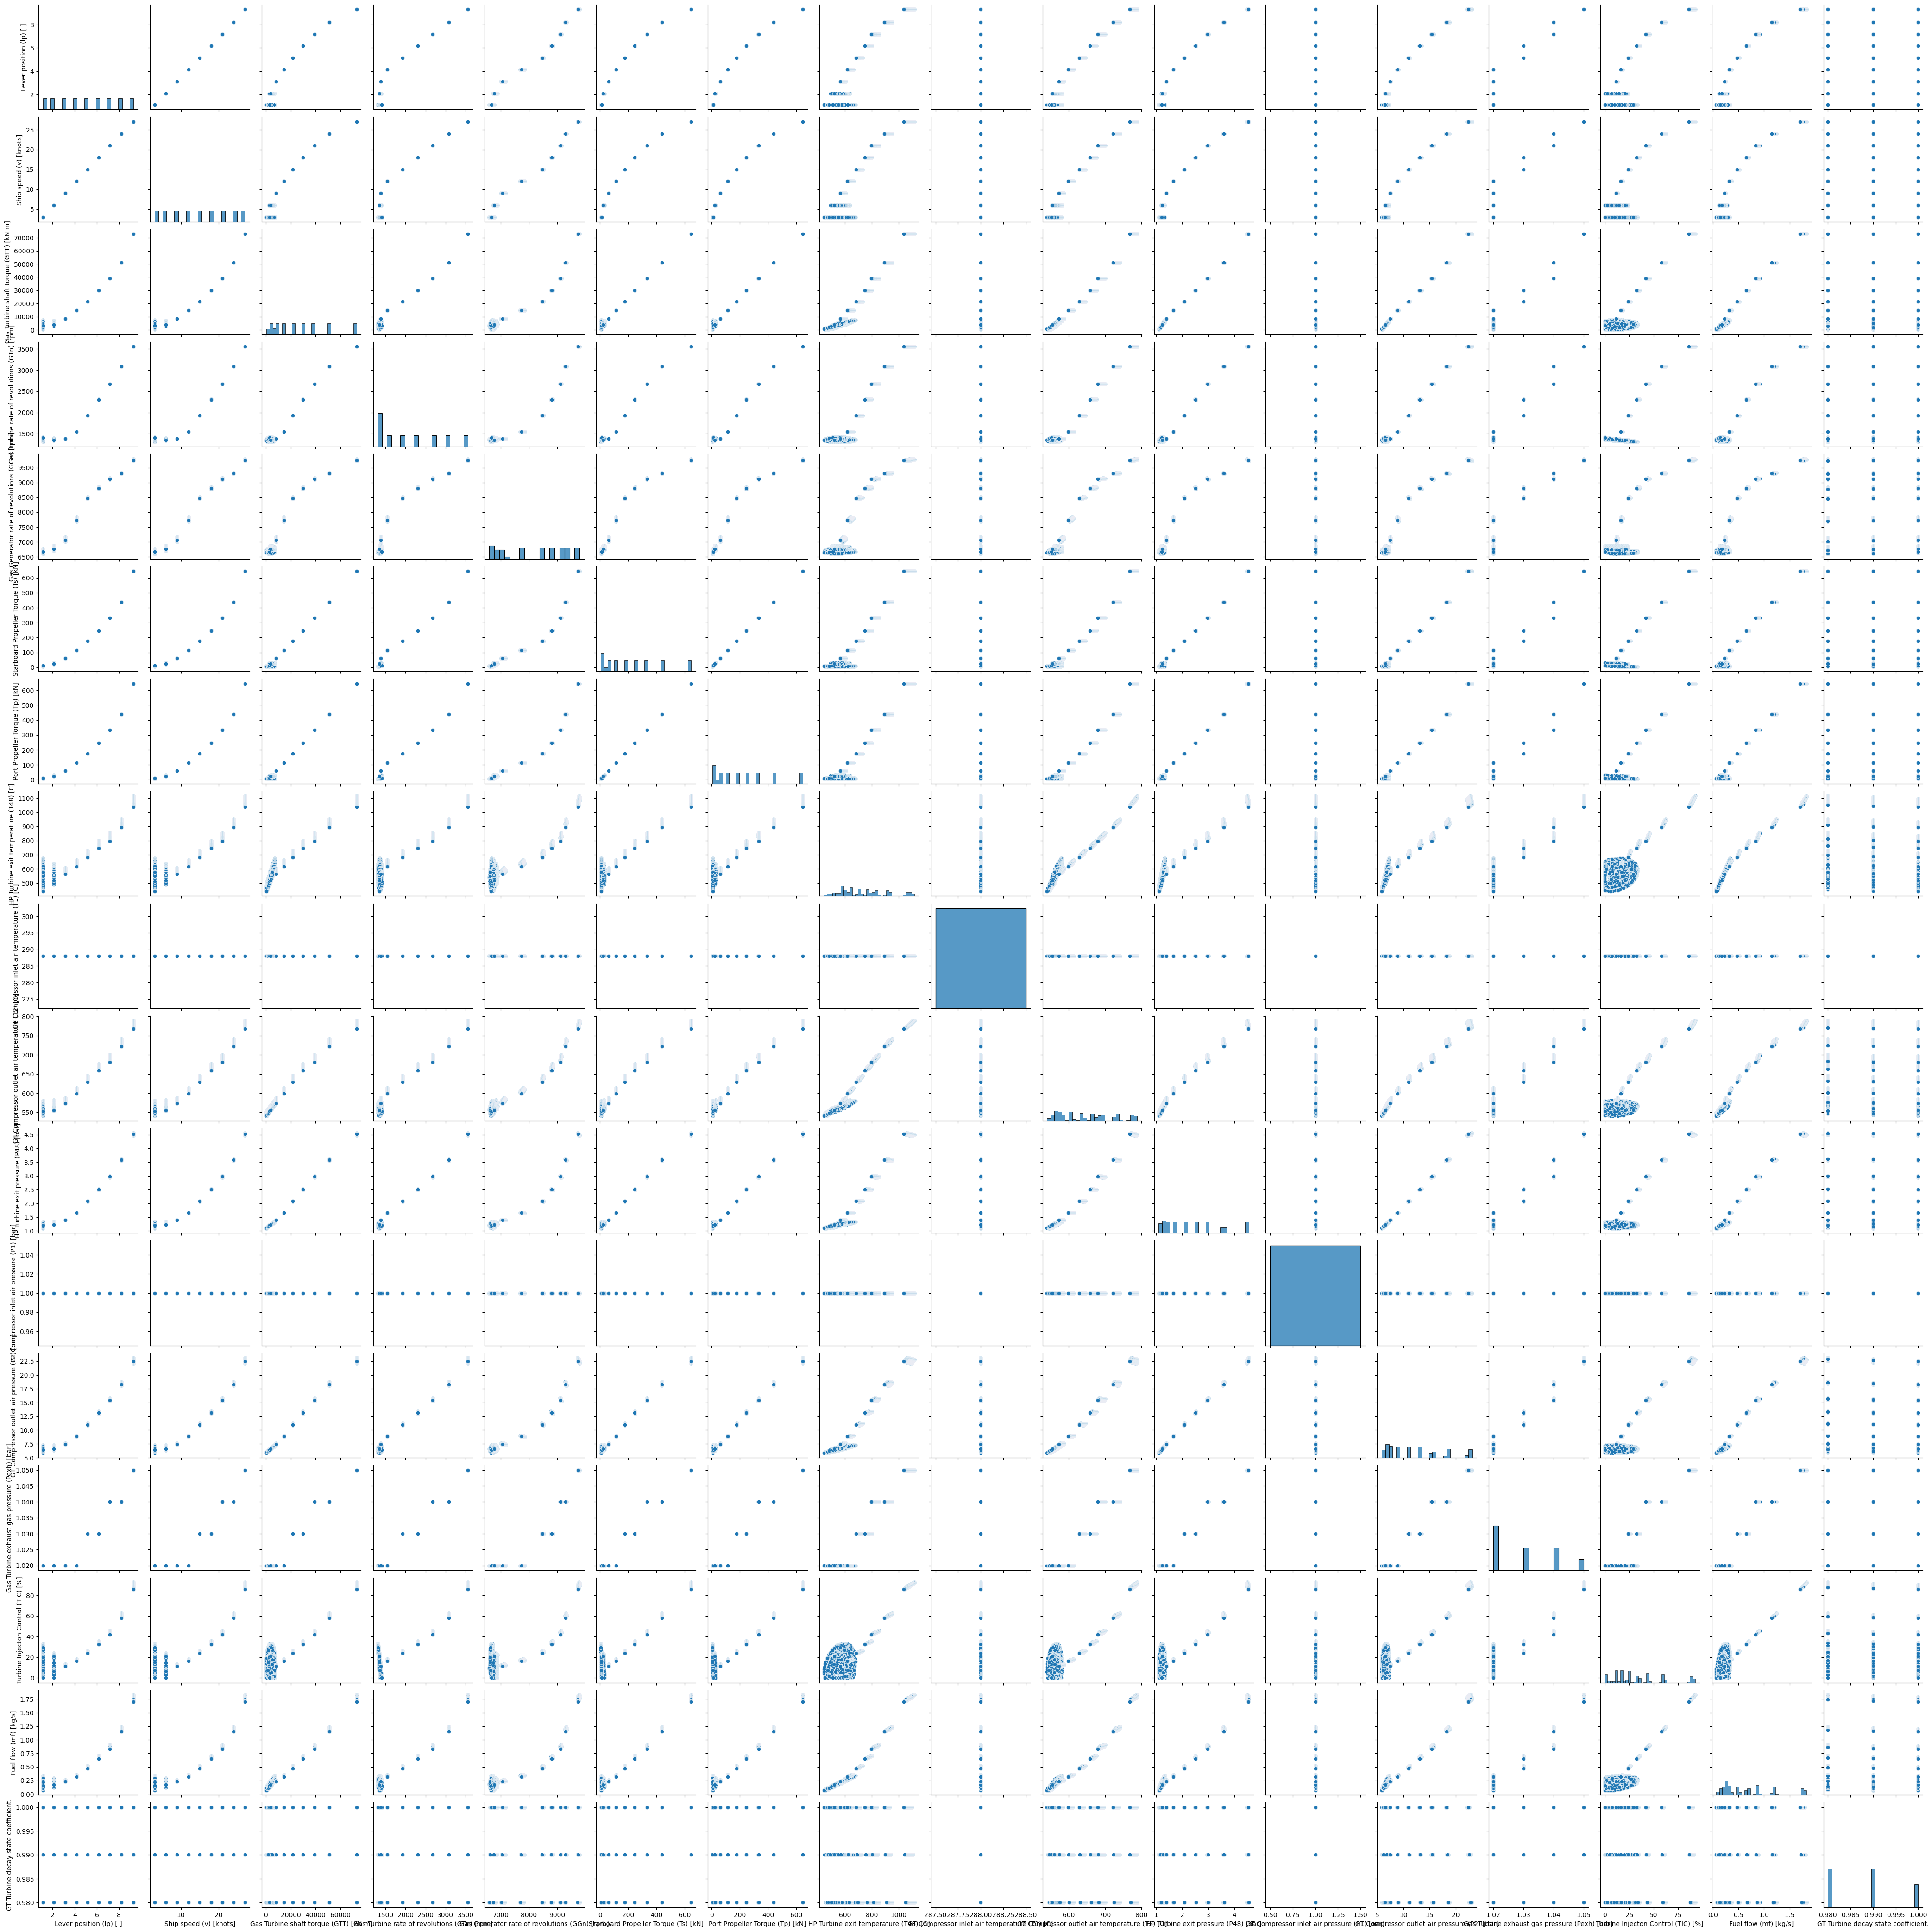

In [33]:
sns.pairplot(data)
plt.show()

In [34]:
#Dropping the Compressor Inlet Temperature and Pressure columns as they are constant across the dataset
data = data.drop(['GT Compressor inlet air temperature (T1) [C]','GT Compressor inlet air pressure (P1) [bar]'], axis = 1)

In [36]:
print(data.dtypes)

Lever position (lp) [ ]                          float64
Ship speed (v) [knots]                           float64
Gas Turbine shaft torque (GTT) [kN m]            float64
Gas Turbine rate of revolutions (GTn) [rpm]      float64
Gas Generator rate of revolutions (GGn) [rpm]    float64
Starboard Propeller Torque (Ts) [kN]             float64
Port Propeller Torque (Tp) [kN]                  float64
HP Turbine exit temperature (T48) [C]            float64
GT Compressor outlet air temperature (T2) [C]    float64
HP Turbine exit pressure (P48) [bar]             float64
GT Compressor outlet air pressure (P2) [bar]     float64
Gas Turbine exhaust gas pressure (Pexh) [bar]    float64
Turbine Injecton Control (TIC) [%]               float64
Fuel flow (mf) [kg/s]                            float64
GT Turbine decay state coefficient.              float64
dtype: object


In [37]:
#Since all columns are of type "float", there is no need to perform One hot encoding on the data

#Splitting the data in to test and train

from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.3, random_state = 100)

In [39]:
#Checking for skewing on the columns
skew_limit = 0.75
skew_vals = train[data.columns].skew()

skew_cols = (skew_vals.sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {0}'.format(skew_limit)))

skew_cols

,Skew
Fuel flow (mf) [kg/s],1.003460
Turbine Injecton Control (TIC) [%],0.899066
Starboard Propeller Torque (Ts) [kN],0.809768
Port Propeller Torque (Tp) [kN],0.809768
Gas Turbine shaft torque (GTT) [kN m],0.768853


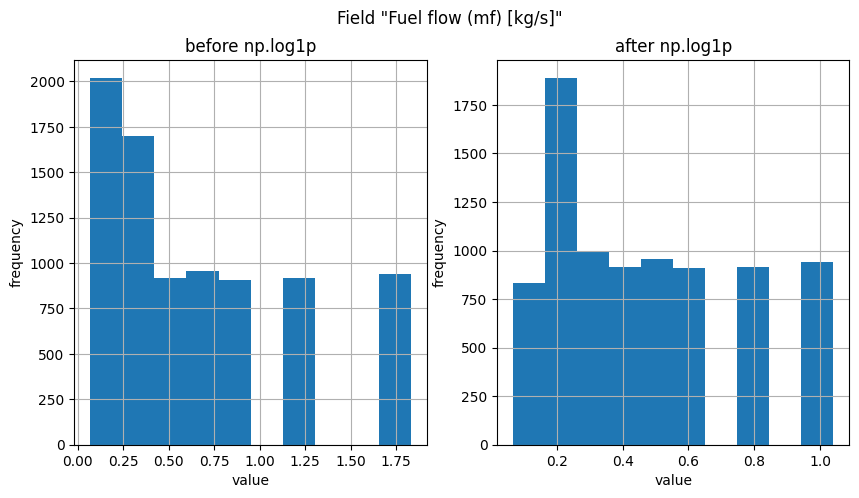

In [40]:
#Applying log transform to the above columns
#Testing the impact on an example column

field = "Fuel flow (mf) [kg/s]"
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))
train[field].hist(ax=ax_before)
train[field].apply(np.log1p).hist(ax=ax_after)
ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')
fig.suptitle('Field "{}"'.format(field));
# a little bit better

In [41]:
#From the above example, using the column with highest skew, there does not seem to be a lot of advantage to applying the log transform
#Hence we will progress as is

Model Development

- I proceeded to develop a linear model using sklearn
- The resulting rmse from comparing the actual to predicted values was close to zero, signifying a near perfect model
- No further optimization attempts such as L1 or L2 regularization was performed


In [42]:
#Separating features from predictor
feature_cols = [x for x in train.columns if x != 'GT Turbine decay state coefficient.']
X_train = train[feature_cols]
y_train = train['GT Turbine decay state coefficient.']

X_test  = test[feature_cols]
y_test  = test['GT Turbine decay state coefficient.']

In [43]:
#Creating a function to calculate rmse (root mean squared error)
from sklearn.metrics import mean_squared_error


def rmse(ytrue, ypredicted):
    return np.sqrt(mean_squared_error(ytrue, ypredicted))

In [44]:
#Creating a basic linear regression model

from sklearn.linear_model import LinearRegression

LR = LinearRegression().fit(X_train, y_train)
LR_rmse = rmse(y_test, LR.predict(X_test))

print(LR_rmse)

0.0035673030745013894


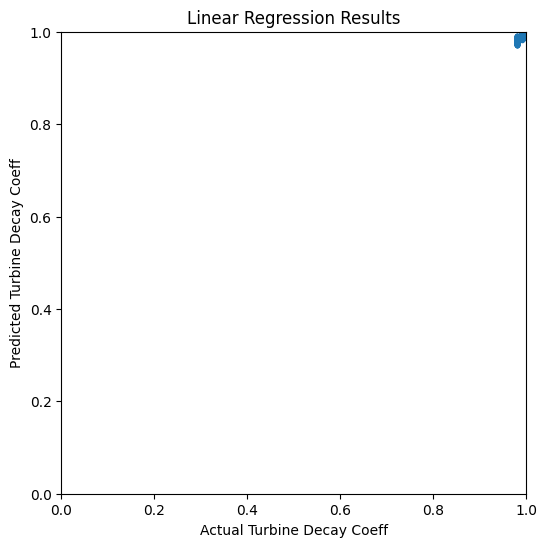

In [47]:
#plotting actual value against predicted value
f = plt.figure(figsize=(6,6))
ax = plt.axes()

ax.plot(y_test, LR.predict(X_test), 
         marker='o', ls='', ms=3.0)

lim = (0, y_test.max())

ax.set(xlabel='Actual Turbine Decay Coeff', 
       ylabel='Predicted Turbine Decay Coeff', 
       xlim=lim,
       ylim=lim,
       title='Linear Regression Results');

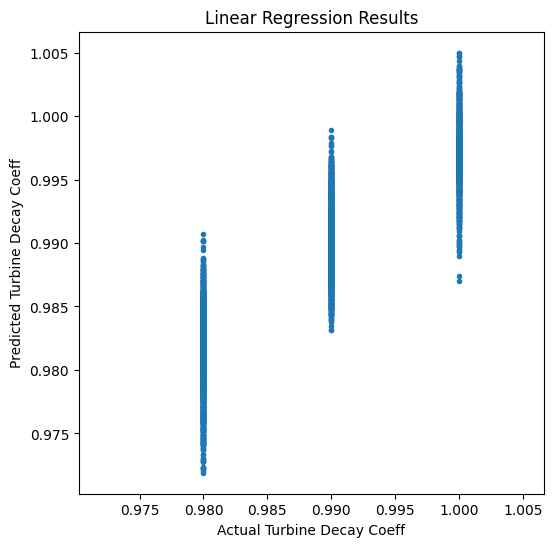

In [48]:
#Stretching out the axis
f = plt.figure(figsize=(6,6))
ax = plt.axes()

ax.plot(y_test, LR.predict(X_test), 
         marker='o', ls='', ms=3.0)

# Determine the limits based on the data
min_value = min(y_test.min(), LR.predict(X_test).min())
max_value = max(y_test.max(), LR.predict(X_test).max())

# Add a small margin to the limits
margin = 0.05 * (max_value - min_value)  # 5% margin
lim = (min_value - margin, max_value + margin)

ax.set(xlabel='Actual Turbine Decay Coeff', 
       ylabel='Predicted Turbine Decay Coeff', 
       xlim=lim,
       ylim=lim,
       title='Linear Regression Results');

Conclusion

The result of this project is a model that very closely (almost perfectly) predicts the GT Turbine Decay Coefficient, with a root mean squared error of close to 0.

This is very likely due to the high correlation between the features and the predictor from the simulation dataset (as shown in the pair wise correlation plot in earlier step). 

In more realistic scenarios this will not be the case and additional steps such as L1/L2 regularization and more complex regression models will be required to build a practical model.